In [1]:
!git clone https://github.com/karolpiczak/ESC-50.git

Cloning into 'ESC-50'...
remote: Enumerating objects: 4199, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 4199 (delta 62), reused 34 (delta 34), pack-reused 4130 (from 1)
Receiving objects: 100% (4199/4199), 878.77 MiB | 15.48 MiB/s, done.
Resolving deltas: 100% (292/292), done.
Updating files: 100% (2011/2011), done.


In [2]:
import librosa
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
from tqdm import tqdm # Biblioteca para mostrar uma barra de progresso
warnings.filterwarnings('ignore')

### 1. Upload do Dataset

Aqui definimos parâmetros como a taxa de amostragem sendo 16kHz e a extração de 40 características acústicas (MFCCs).

Definimos que as categorias 0 a 24 seriam o som padrão do ambiente, enquanto as categorias 40 a 49 seriam as anomalias.

Dividimos os sons normais em 80% para treino e 20% para teste, enquanto 100% dos sons anômalos são reservados para teste, isso porque o sistema aprende apenas o que é "normal".

In [3]:
caminho_csv = 'ESC-50/meta/esc50.csv'
pasta_audio = 'ESC-50/audio/'

In [4]:
#TAXA_AMOSTRAGEM = 16000
#N_MFCC = 40

In [5]:
df = pd.read_csv(caminho_csv)

In [6]:
# ==========================================
# 1. SEPARAÇÃO DOS ÁUDIOS
# ==========================================

# Normal: classes 0 a 24
df_normal = df[df['target'] <= 24].copy()

# Anomalia: classes 40 a 49
df_anomalia = df[df['target'] >= 40].copy()

# Divisão por ÁUDIO, antes da extração dos frames
df_treino_normal, df_teste_normal = train_test_split(
    df_normal,
    test_size=0.20,
    random_state=42
)

print("=== DIVISÃO DOS ÁUDIOS ===")
print(f"Áudios normais para treino: {len(df_treino_normal)}")
print(f"Áudios normais para teste: {len(df_teste_normal)}")
print(f"Áudios anômalos para teste: {len(df_anomalia)}")

=== DIVISÃO DOS ÁUDIOS ===
Áudios normais para treino: 800
Áudios normais para teste: 200
Áudios anômalos para teste: 400


In [7]:
df_treino_normal.head()

,filename,fold,target,category,esc10,src_file,take
66,1-17808-A-12.wav,1,12,crackling_fire,True,17808,A
1070,3-162786-A-13.wav,3,13,crickets,False,162786,A
1392,4-176914-A-23.wav,4,23,breathing,False,176914,A
1112,3-177082-A-22.wav,3,22,clapping,False,177082,A
1685,5-187201-B-4.wav,5,4,frog,False,187201,B


Carregar os audios a 16kz, extrair 40 mfccs, delta e delta 2,

In [8]:
import librosa
import numpy as np

def extrair_frames(caminho):
    y, sr = librosa.load(caminho, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    # Concatena as features e transpõe para (frames, features)
    return np.vstack([mfcc, delta, delta2]).T

In [9]:
def processar_dataset(df, pasta_audio):

    todos_frames = []

    for _, linha in df.iterrows():

        caminho = os.path.join(
            pasta_audio,
            linha["filename"]
        )

        features = extrair_frames(caminho)

        todos_frames.append(features)

    # Empilha os frames de todos os áudios
    return np.vstack(todos_frames)

In [10]:
X_treino = processar_dataset(
    df_treino_normal,
    pasta_audio
)

X_teste_normal = processar_dataset(
    df_teste_normal,
    pasta_audio
)

X_teste_anomalia = processar_dataset(
    df_anomalia,
    pasta_audio
)

In [11]:
print(X_teste_normal.shape)
# aproximadamente (43200, 120)

print(X_teste_anomalia.shape)
# aproximadamente (86400, 120)

(31400, 120)
(62800, 120)


In [12]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_treino)
treino_escalonado = scaler.transform(X_treino)

gmm = GaussianMixture(n_components=16, covariance_type='diag')
gmm.fit(treino_escalonado)

GaussianMixture(covariance_type='diag', n_components=16)

Juntando 157 frames em cada audio de novo, e calculando diversas metricas (média, min, mediana, percentil, etc) pra ver qual representa melhor

In [14]:
import numpy as np
from sklearn.metrics import roc_auc_score

# 1. Escalonar os dados de teste e extrair o log-likelihood de cada frame
scores_normal_frames = gmm.score_samples(scaler.transform(X_teste_normal))
scores_anomalia_frames = gmm.score_samples(scaler.transform(X_teste_anomalia))

# 2. Reconstruir a matriz para (quantidade de áudios, 157 frames)
FRAMES_POR_AUDIO = 157
scores_normal_matriz = scores_normal_frames.reshape(-1, FRAMES_POR_AUDIO)
scores_anomalia_matriz = scores_anomalia_frames.reshape(-1, FRAMES_POR_AUDIO)

# 3. Extrair as diferentes estatísticas matemáticas ao longo dos frames (axis=1)
# Características dos áudios Normais
feat_normal_media = scores_normal_matriz.mean(axis=1)
feat_normal_min = scores_normal_matriz.min(axis=1)
feat_normal_p10 = np.percentile(scores_normal_matriz, 10, axis=1)
feat_normal_std = scores_normal_matriz.std(axis=1)

# Características dos áudios de Anomalia
feat_anomalia_media = scores_anomalia_matriz.mean(axis=1)
feat_anomalia_min = scores_anomalia_matriz.min(axis=1)
feat_anomalia_p10 = np.percentile(scores_anomalia_matriz, 10, axis=1)
feat_anomalia_std = scores_anomalia_matriz.std(axis=1)

# 4. Avaliar o poder de separação de cada métrica
def comparar_metricas(normal_scores, anomalia_scores, nome):
    # 0 para Normal (200 áudios), 1 para Anomalia (400 áudios)
    y_true = np.concatenate([np.zeros(200), np.ones(400)])

    # Valores de probabilidade menores indicam anomalia (multiplicamos por -1)
    # Exceção: Desvio padrão alto indica anomalia (mantém o sinal)
    sinal = 1 if nome == 'Desvio Padrão' else -1
    y_scores = sinal * np.concatenate([normal_scores, anomalia_scores])

    auc = roc_auc_score(y_true, y_scores)
    print(f"ROC-AUC ({nome}): {auc:.4f}")

# 5. Imprimir os resultados finais
comparar_metricas(feat_normal_media, feat_anomalia_media, "Média")
comparar_metricas(feat_normal_min, feat_anomalia_min, "Mínimo")
comparar_metricas(feat_normal_p10, feat_anomalia_p10, "Percentil 10")
comparar_metricas(feat_normal_std, feat_anomalia_std, "Desvio Padrão")

ROC-AUC (Média): 0.5385
ROC-AUC (Mínimo): 0.3636
ROC-AUC (Percentil 10): 0.3707
ROC-AUC (Desvio Padrão): 0.3355


### 2. Processamento e Análise Exploratória

Aqui convertemos os arquivos de áudio bruto em matrizes matemáticas.
Primeiro convertemos cada áudio para canal único (mono), aplicamos a taxa de amostragem como 16kHz, e extraímos os 40 Coeficientes Cepstrais de Frequência Mel (MFCCs): divide o áudio em frames e mapeia as frequências de forma semelhante a como o ouvido humano percebe o som.
Além disso, é calculado delta (derivada de 1 ordem) que mede a velocidade com que as características do som mudam, e delta-delta (derivada de 2 ordem) que calcula a aceleração das mudanças.
As três matrizes (MFCC, Delta e Delta-Delta) são empilhadas, resultando em 120 características por frame, sendo cada característica 1 coluna e cada frame 1 linha.

In [7]:
# ==========================================
# 2. EXTRAÇÃO DOS MFCCs por áudio
# ==========================================

def extrair_mfcc_por_audio(df_audios):

    dados_audios = []

    for index, row in tqdm(
        df_audios.iterrows(),
        total=len(df_audios)
    ):

        caminho_completo = os.path.join(
            pasta_audio,
            row['filename']
        )

        # 1. Carregamento e padronização
        y, sr = librosa.load(
            caminho_completo,
            sr=TAXA_AMOSTRAGEM,
            mono=True
        )

        # 2. MFCC
        mfccs = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_mfcc=N_MFCC
        )

        # 3. Delta
        mfcc_delta = librosa.feature.delta(mfccs)

        # 4. Delta-Delta
        mfcc_delta2 = librosa.feature.delta(
            mfccs,
            order=2
        )

        # 5. Combina as características
        mfccs_combinados = np.vstack(
            (mfccs, mfcc_delta, mfcc_delta2)
        )

        # 6. Transpõe:
        #    linhas = frames
        #    colunas = features
        frames = mfccs_combinados.T

        # Guarda o áudio inteiro como uma unidade
        dados_audios.append({
            'filename': row['filename'],
            'target': row['target'],
            'classe': row['category'],
            'frames': frames
        })

    return dados_audios

Aqui realizamos a partição do dataset para alimentar os algoritmos não supervisionados e supervisionados

In [8]:
# ==========================================
# DIVISÃO DOS ÁUDIOS
# ==========================================

# ------------------------------------------
# 1. SEPARAÇÃO DAS CLASSES
# ------------------------------------------

# Normais: classes 0 a 24
df_normal = df[
    df['target'] <= 24
].copy()

# Anomalias: classes 40 a 49
df_anomalia = df[
    df['target'] >= 40
].copy()


# ------------------------------------------
# 2. DIVISÃO DOS ÁUDIOS NORMAIS
# ------------------------------------------

# 80% para treino
# 20% para teste

df_treino_normal, df_teste_normal = train_test_split(
    df_normal,
    test_size=0.20,
    random_state=42
)


# ------------------------------------------
# 3. DIVISÃO DOS ÁUDIOS ANÔMALOS
# ------------------------------------------

# Classes 40 a 44: Anomalias para treino do Naive Bayes (ex: sirene, choro, etc.)
df_treino_anomalia = df[
    (df['target'] >= 40) & (df['target'] <= 44)
].copy()

# Classes 45 a 49: Anomalias inéditas para o teste final de todos os modelos
df_teste_anomalia = df[
    (df['target'] >= 45) & (df['target'] <= 49)
].copy()


# ------------------------------------------
# 4. INFORMAÇÕES DA DIVISÃO
# ------------------------------------------

print("=== DIVISÃO DOS ÁUDIOS ===")

print(
    f"Áudios normais para treino: "
    f"{len(df_treino_normal)}"
)

print(
    f"Áudios normais para teste: "
    f"{len(df_teste_normal)}"
)

print(
    f"Áudios anômalos para treino (NB): "
    f"{len(df_treino_anomalia)}"
)

print(
    f"Áudios anômalos para teste: "
    f"{len(df_teste_anomalia)}"
)


# ------------------------------------------
# 5. EXTRAÇÃO DOS MFCCs
# ------------------------------------------

print("\nExtraindo MFCCs dos áudios de TREINO NORMAL...")

audios_treino = extrair_mfcc_por_audio(
    df_treino_normal
)


print("\nExtraindo MFCCs dos áudios ANÔMALOS DE TREINO...")

audios_treino_anomalia = extrair_mfcc_por_audio(
    df_treino_anomalia
)


print("\nExtraindo MFCCs dos áudios NORMAIS DE TESTE...")

audios_teste_normal = extrair_mfcc_por_audio(
    df_teste_normal
)


print("\nExtraindo MFCCs dos áudios ANÔMALOS DE TESTE...")

audios_teste_anomalia = extrair_mfcc_por_audio(
    df_teste_anomalia
)

=== DIVISÃO DOS ÁUDIOS ===
Áudios normais para treino: 800
Áudios normais para teste: 200
Áudios anômalos para treino (NB): 200
Áudios anômalos para teste: 200

Extraindo MFCCs dos áudios de TREINO NORMAL...


100%|██████████| 800/800 [00:51<00:00, 15.49it/s]



Extraindo MFCCs dos áudios ANÔMALOS DE TREINO...


100%|██████████| 200/200 [00:05<00:00, 34.60it/s]



Extraindo MFCCs dos áudios NORMAIS DE TESTE...


100%|██████████| 200/200 [00:05<00:00, 36.36it/s]



Extraindo MFCCs dos áudios ANÔMALOS DE TESTE...


100%|██████████| 200/200 [00:06<00:00, 30.55it/s]


Dividindo em janelas

In [9]:
# ==========================================
# EXPERIMENTO B - PRESERVAÇÃO TEMPORAL
# ==========================================

N_JANELAS = 4


def dividir_em_janelas(frames, n_janelas=N_JANELAS):

    n_frames = frames.shape[0]

    tamanho = n_frames // n_janelas

    janelas = []

    for i in range(n_janelas):

        inicio = i * tamanho

        if i == n_janelas - 1:
            fim = n_frames
        else:
            fim = (i + 1) * tamanho

        janelas.append(frames[inicio:fim])

    return janelas


def extrair_estatisticas_janelas(audios):

    dados = []
    ids_audio = []
    posicoes_janela = []

    for audio in audios:

        frames = audio['frames']

        janelas = dividir_em_janelas(frames)

        for i, janela in enumerate(janelas):

            media = np.mean(janela, axis=0)

            desvio_padrao = np.std(janela, axis=0)

            vetor = np.concatenate([
                media,
                desvio_padrao
            ])

            dados.append(vetor)

            ids_audio.append(audio['filename'])

            posicoes_janela.append(i)

    return (
        np.array(dados),
        np.array(ids_audio),
        np.array(posicoes_janela)
    )


# ==========================================
# CRIAÇÃO DAS JANELAS
# ==========================================

X_treino_janelas, ids_treino, pos_treino = \
    extrair_estatisticas_janelas(audios_treino)

X_teste_normal_janelas, ids_normal, pos_normal = \
    extrair_estatisticas_janelas(audios_teste_normal)

X_teste_anomalia_janelas, ids_anomalia, pos_anomalia = \
    extrair_estatisticas_janelas(audios_teste_anomalia)


print("=== FORMATO DOS DADOS ===")

print(f"Treino normal: {X_treino_janelas.shape}")
print(f"Teste normal: {X_teste_normal_janelas.shape}")
print(f"Teste anomalia: {X_teste_anomalia_janelas.shape}")

=== FORMATO DOS DADOS ===
Treino normal: (3200, 240)
Teste normal: (800, 240)
Teste anomalia: (800, 240)


Tirando o PCa

In [10]:
# ==========================================
# NORMALIZAÇÃO
# ==========================================

scaler = StandardScaler()

# O scaler aprende SOMENTE com as janelas
# dos áudios normais de treinamento

X_treino_janelas = scaler.fit_transform(
    X_treino_janelas
)

X_teste_normal_janelas = scaler.transform(
    X_teste_normal_janelas
)

X_teste_anomalia_janelas = scaler.transform(
    X_teste_anomalia_janelas
)


print("=== NORMALIZAÇÃO CONCLUÍDA ===")

print(f"Treino: {X_treino_janelas.shape}")
print(f"Teste normal: {X_teste_normal_janelas.shape}")
print(f"Teste anomalia: {X_teste_anomalia_janelas.shape}")

=== NORMALIZAÇÃO CONCLUÍDA ===
Treino: (3200, 240)
Teste normal: (800, 240)
Teste anomalia: (800, 240)


In [11]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# PREPARAR DADOS PARA O t-SNE
# ==========================================

# Junta todas as janelas
X_tsne = np.vstack([
    X_treino_janelas,
    X_teste_normal_janelas,
    X_teste_anomalia_janelas
])

# Identifica a origem de cada janela
labels_tsne = np.concatenate([
    np.zeros(len(X_treino_janelas)),                  # Normal - treino
    np.ones(len(X_teste_normal_janelas)),             # Normal - teste
    np.full(len(X_teste_anomalia_janelas), 2)         # Anomalia
])

print("Shape para t-SNE:", X_tsne.shape)

Shape para t-SNE: (4800, 240)


In [12]:
# ==========================================
# PCA PRÉVIO
# ==========================================

pca_tsne = PCA(n_components=30, random_state=42)

X_tsne_pca = pca_tsne.fit_transform(X_tsne)

print("Shape após PCA:", X_tsne_pca.shape)

Shape após PCA: (4800, 30)


In [13]:
# ==========================================
# t-SNE
# ==========================================

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    max_iter=1000
)

X_tsne_2d = tsne.fit_transform(X_tsne_pca)

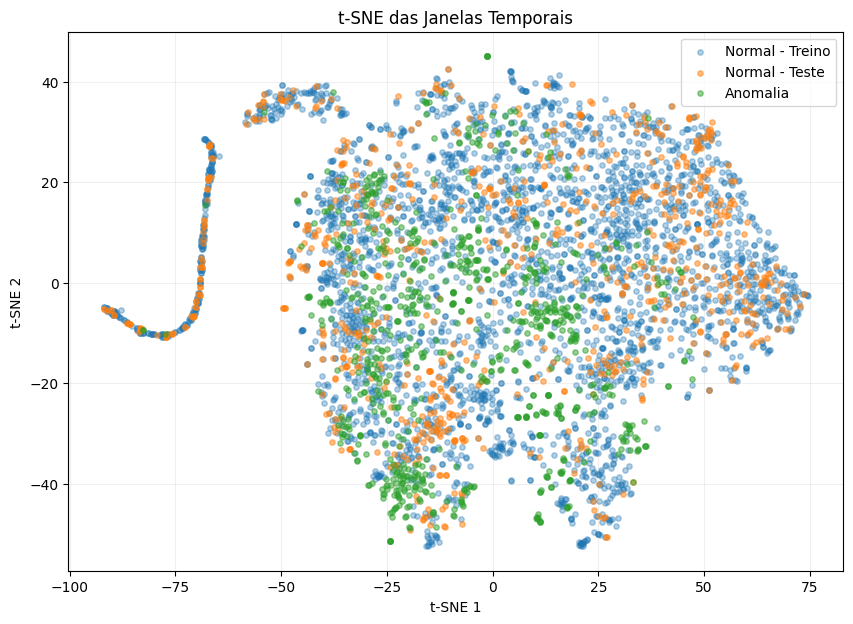

In [14]:
# ==========================================
# GRÁFICO t-SNE
# ==========================================

plt.figure(figsize=(10, 7))

plt.scatter(
    X_tsne_2d[labels_tsne == 0, 0],
    X_tsne_2d[labels_tsne == 0, 1],
    alpha=0.35,
    s=15,
    label="Normal - Treino"
)

plt.scatter(
    X_tsne_2d[labels_tsne == 1, 0],
    X_tsne_2d[labels_tsne == 1, 1],
    alpha=0.5,
    s=15,
    label="Normal - Teste"
)

plt.scatter(
    X_tsne_2d[labels_tsne == 2, 0],
    X_tsne_2d[labels_tsne == 2, 1],
    alpha=0.5,
    s=15,
    label="Anomalia"
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE das Janelas Temporais")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [15]:
# ==========================================
# VERIFICAÇÃO DAS JANELAS
# ==========================================

print("Número de janelas do primeiro áudio:")

janelas = dividir_em_janelas(
    audios_treino[0]['frames']
)

for i, janela in enumerate(janelas):

    print(
        f"Janela {i+1}: "
        f"{janela.shape}"
    )

Número de janelas do primeiro áudio:
Janela 1: (39, 120)
Janela 2: (39, 120)
Janela 3: (39, 120)
Janela 4: (40, 120)


Aqui unificamos os audios normais e anomalos de teste, e definimos 0 como audios normais e 1 para anomalos.

In [16]:
# ==========================================
# GMM - TREINAMENTO
# ==========================================

gmm = GaussianMixture(
    n_components=5,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_treino_janelas)

print("GMM treinado.")

GMM treinado.


In [17]:
# ==========================================
# SCORE DAS JANELAS
# ==========================================

scores_treino = gmm.score_samples(
    X_treino_janelas
)

scores_teste_normal = gmm.score_samples(
    X_teste_normal_janelas
)

scores_teste_anomalia = gmm.score_samples(
    X_teste_anomalia_janelas
)


print("Scores calculados.")

Scores calculados.


In [18]:
# ==========================================
# AGREGAR SCORES POR ÁUDIO
# ==========================================

def agregar_scores_por_audio(scores, ids_audio):

    df_scores = pd.DataFrame({
        'audio': ids_audio,
        'score': scores
    })

    scores_audio = (
        df_scores
        .groupby('audio')['score']
        .min()
    )

    return scores_audio


scores_treino_audio = agregar_scores_por_audio(
    scores_treino,
    ids_treino
)

scores_normal_audio = agregar_scores_por_audio(
    scores_teste_normal,
    ids_normal
)

scores_anomalia_audio = agregar_scores_por_audio(
    scores_teste_anomalia,
    ids_anomalia
)


print("=== SCORES POR ÁUDIO ===")

print(
    f"Treino: {len(scores_treino_audio)}"
)

print(
    f"Teste normal: {len(scores_normal_audio)}"
)

print(
    f"Teste anomalia: {len(scores_anomalia_audio)}"
)

=== SCORES POR ÁUDIO ===
Treino: 800
Teste normal: 200
Teste anomalia: 200


In [19]:
# ==========================================
# THRESHOLD
# ==========================================

threshold = np.percentile(
    scores_treino_audio,
    5
)

print(f"Threshold: {threshold:.4f}")

Threshold: -288.6122


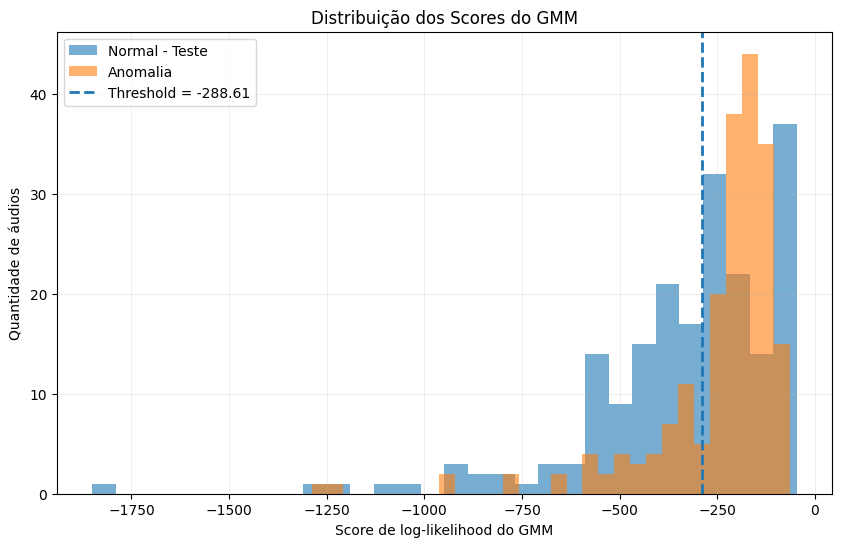

In [20]:
# ==========================================
# DISTRIBUIÇÃO DOS SCORES DO GMM
# ==========================================

plt.figure(figsize=(10, 6))

plt.hist(
    scores_normal_audio,
    bins=30,
    alpha=0.6,
    label="Normal - Teste"
)

plt.hist(
    scores_anomalia_audio,
    bins=30,
    alpha=0.6,
    label="Anomalia"
)

plt.axvline(
    threshold,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {threshold:.2f}"
)

plt.xlabel("Score de log-likelihood do GMM")
plt.ylabel("Quantidade de áudios")
plt.title("Distribuição dos Scores do GMM")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [21]:
# ==========================================
# CLASSIFICAÇÃO
# ==========================================

scores_teste = np.concatenate([
    scores_normal_audio.values,
    scores_anomalia_audio.values
])

y_teste = np.concatenate([
    np.zeros(len(scores_normal_audio)),
    np.ones(len(scores_anomalia_audio))
])

y_pred = (
    scores_teste < threshold
).astype(int)

In [22]:
# ==========================================
# SCORE DAS 4 JANELAS
# ==========================================

def preparar_scores_janelas(scores, ids_audio, posicoes):
    dados = []

    for audio, score, pos in zip(ids_audio, scores, posicoes):
        dados.append([audio, pos + 1, score])

    return np.array(dados, dtype=object)


scores_normal_janelas_df = preparar_scores_janelas(
    scores_teste_normal,
    ids_normal,
    pos_normal
)

scores_anomalia_janelas_df = preparar_scores_janelas(
    scores_teste_anomalia,
    ids_anomalia,
    pos_anomalia
)

In [23]:
# ==========================================
# AVALIAÇÃO
# ==========================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score
)

print("=== MATRIZ DE CONFUSÃO ===")

print(
    confusion_matrix(
        y_teste,
        y_pred
    )
)

print("\n=== MÉTRICAS ===")

print(
    classification_report(
        y_teste,
        y_pred,
        target_names=[
            'Normal',
            'Anomalia'
        ]
    )
)

print(
    f"Accuracy: "
    f"{accuracy_score(y_teste, y_pred):.4f}"
)

print(
    f"Balanced Accuracy: "
    f"{balanced_accuracy_score(y_teste, y_pred):.4f}"
)

=== MATRIZ DE CONFUSÃO ===
[[105  95]
 [154  46]]

=== MÉTRICAS ===
              precision    recall  f1-score   support

      Normal       0.41      0.53      0.46       200
    Anomalia       0.33      0.23      0.27       200

    accuracy                           0.38       400
   macro avg       0.37      0.38      0.36       400
weighted avg       0.37      0.38      0.36       400

Accuracy: 0.3775
Balanced Accuracy: 0.3775


# Mais algumas análises de dados

NaN: 0
Inf: 0

Variância mínima: 0.9999962
Variância máxima: 1.0000045
Features com variância < 0.01: 0


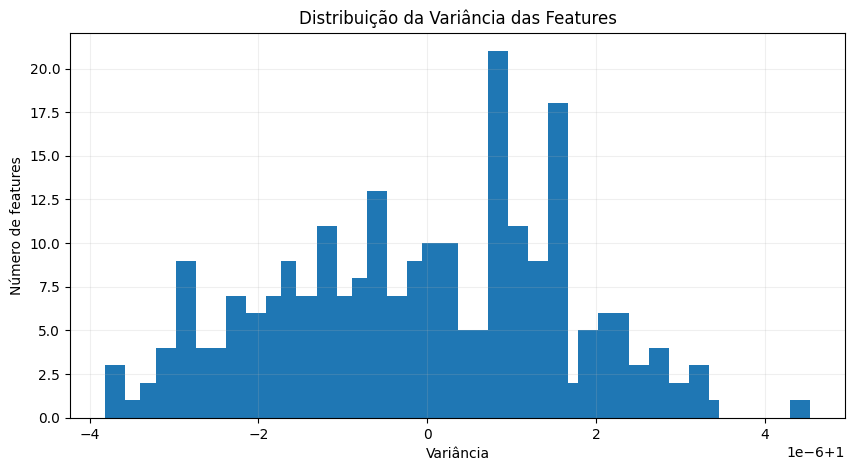

In [24]:
# ==========================================
# QUALIDADE DAS FEATURES
# ==========================================

print("NaN:", np.isnan(X_treino_janelas).sum())
print("Inf:", np.isinf(X_treino_janelas).sum())

variancias = np.var(X_treino_janelas, axis=0)

print("\nVariância mínima:", variancias.min())
print("Variância máxima:", variancias.max())
print("Features com variância < 0.01:", np.sum(variancias < 0.01))

plt.figure(figsize=(10, 5))

plt.hist(variancias, bins=40)

plt.xlabel("Variância")
plt.ylabel("Número de features")
plt.title("Distribuição da Variância das Features")
plt.grid(alpha=0.2)

plt.show()

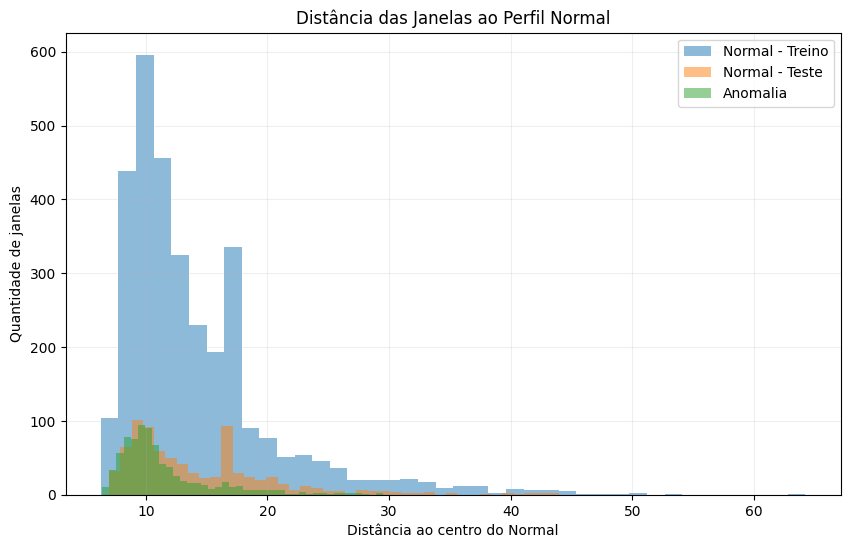

In [25]:
# ==========================================
# DISTÂNCIA AO CENTRO DO NORMAL
# ==========================================

centro_normal = np.mean(X_treino_janelas, axis=0)

dist_treino = np.linalg.norm(
    X_treino_janelas - centro_normal,
    axis=1
)

dist_normal = np.linalg.norm(
    X_teste_normal_janelas - centro_normal,
    axis=1
)

dist_anomalia = np.linalg.norm(
    X_teste_anomalia_janelas - centro_normal,
    axis=1
)

plt.figure(figsize=(10, 6))

plt.hist(
    dist_treino,
    bins=40,
    alpha=0.5,
    label="Normal - Treino"
)

plt.hist(
    dist_normal,
    bins=40,
    alpha=0.5,
    label="Normal - Teste"
)

plt.hist(
    dist_anomalia,
    bins=40,
    alpha=0.5,
    label="Anomalia"
)

plt.xlabel("Distância ao centro do Normal")
plt.ylabel("Quantidade de janelas")
plt.title("Distância das Janelas ao Perfil Normal")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

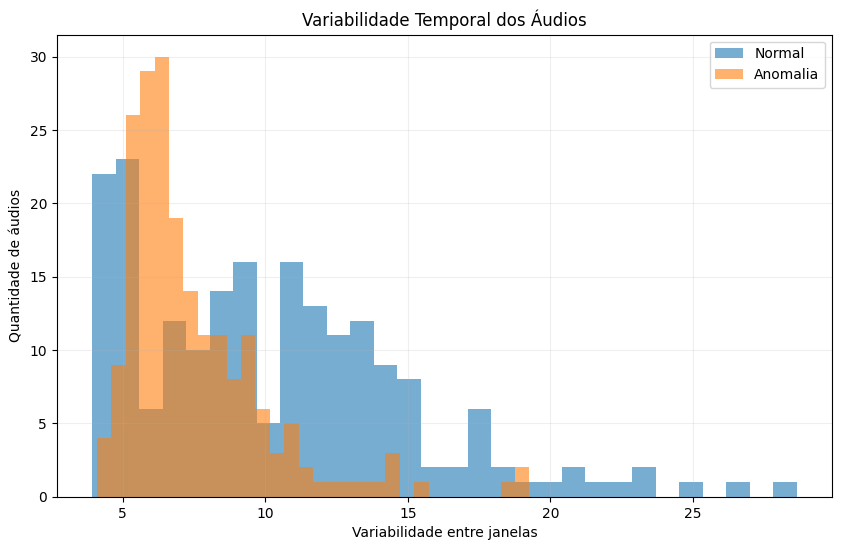

In [26]:
# ==========================================
# VARIABILIDADE TEMPORAL
# ==========================================

def calcular_variabilidade_temporal(X, ids_audio):
    variabilidades = []

    for audio in np.unique(ids_audio):
        mascara = ids_audio == audio
        janelas = X[mascara]

        # Distância entre cada janela e a média do próprio áudio
        centro = np.mean(janelas, axis=0)

        distancia = np.mean(
            np.linalg.norm(janelas - centro, axis=1)
        )

        variabilidades.append(distancia)

    return np.array(variabilidades)


var_normal = calcular_variabilidade_temporal(
    X_teste_normal_janelas,
    ids_normal
)

var_anomalia = calcular_variabilidade_temporal(
    X_teste_anomalia_janelas,
    ids_anomalia
)

plt.figure(figsize=(10, 6))

plt.hist(
    var_normal,
    bins=30,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    var_anomalia,
    bins=30,
    alpha=0.6,
    label="Anomalia"
)

plt.xlabel("Variabilidade entre janelas")
plt.ylabel("Quantidade de áudios")
plt.title("Variabilidade Temporal dos Áudios")
plt.legend()
plt.grid(alpha=0.2)

plt.show()